Task: Write a piece of code and use it to perform numerical experiments that empirically
demonstrate that Multi-Layer Perceptrons  can approximate a large class of continuous functions.


What is a Multi-Layer Perceptron?

An MLP is a type of neural network consisting of at least three layers:
 an input layer, one or more hidden layers, and an output layer.
 Each neuron in one layer is connected to every neuron in the next layer.
 The MLP learns by adjusting the weights of these connections to minimize the error of its predictions, using a process called backpropagation.


Import Libraries

In [18]:
#!pip install requirements.txt
import numpy as np
import base64
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib import animation
from pathlib import Path
from IPython.display import HTML

Parameters Setup

In [19]:
seed = 777  # so we can reproduce the same results each time we run the code (pseudo-random number generation)
np.random.seed(seed)
torch.manual_seed(seed)

Use GPU if available, which can significantly speed up training for larger models and datasets. In this case, it's not strictly necessary due to the small scale of our experiment, but it's good practice to include it.

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Target Functions

They were generated using a prompt 'Create a Python dictionary TARGET_FUNCTIONS that will contain a diverse set of mathematical functions to test MLP approximation. Include periodic, exponential decay, non-differentiable and non-linear types. Each should be a tuple of a lambda function and an x-axis rang' to Gemini.

In [21]:
# name, function, and range pairs to test the MLP's approximation capabilities
TARGET_FUNCTIONS = {
    "sin(x)": (lambda x: np.sin(x), (-6, 6)),
    "cos(2x)·e^(-x²/4)": (lambda x: np.cos(2 * x) * np.exp(-x ** 2 / 4), (-4, 4)),
    "|x|": (lambda x: np.abs(x), (-3, 3)),
    "x²·sin(x)": (lambda x: x ** 2 * np.sin(x), (-5, 5)),
    "tanh(5x)": (lambda x: np.tanh(5 * x), (-2, 2)),
    "sawtooth-like": (lambda x: x - np.floor(x), (0, 4)),
}  # the sawtooth function is intentionally included as a  it is discontinuous negative control

 Generate Training Data

For each function we sample `n` evenly-spaced points from its domain. The model requires discrete data. It sees $(x_i,\, f(x_i))$ pairs and must learn to reproduce $f$.

In [22]:
def generate_data(function, n=256, x_min=-2.0, x_max=2.0):
    x = np.linspace(x_min, x_max, n).reshape(-1, 1).astype(np.float32)
    # generate n points between x_min and x_max, reshape to be a column vector, and convert to float32 for better performance with PyTorch
    y = function(x).astype(np.float32)
    x_t = torch.tensor(x, device=device)
    y_t = torch.tensor(y, device=device)
    return x, y, x_t, y_t


Model Creation and Training

We define a simple MLP with two hidden layers of configurable width.
We define our neural network by subclassing nn.Module, and initialize the neural network layers in __init__. Every nn.Module subclass implements the operations on input data in the forward method.

torch.nn is PyTorch's neural network library that provides the building blocks for creating deep learning models. `hidden` determines the "width" of the network, meaning how many neurons there are in the hidden layers


In [23]:
# class from pytorch library implements the multi-layer perceptron (MLP) module.
class MLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),  # input layer to first hidden layer
            nn.Tanh(),  # activation function to introduce non-linearity
            nn.Linear(hidden, hidden),  # first hidden layer to second hidden layer
            nn.Tanh(),
            nn.Linear(hidden, 1),  # output layer, takes signals from 32 neurons and squishes them back to 1 value
        )

    def forward(self, x):
        return self.net(x)


In [24]:
model = MLP().to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


Model Training

Training the MLP involves defining a loss function (MSELoss for regression tasks), an optimizer (Adam - an adaptive gradient descent method that adjusts the learning rate per parameter, converging faster than vanilla SGD on these small regression tasks), and a training loop that iteratively updates the model's weights to minimize the loss. Step counter is used because in real problems the error rarely reaches perfect zero.
During training we snapshot the predictions every `record_every` steps so we can animate the convergence afterwards.

In [25]:
def train(model, x_t, y_t, steps=2000, lr=1e-3, record_every=25):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    # we use the mean square error (MSELoss) function to measure how far the model predictions deviate from the true function
    loss_fn = nn.MSELoss()

    history = {
        "step": [],
        "loss": [],
        "preds": []  # snapshots (for GIF)
    }

    for step in range(steps + 1):
        model.train()
        pred = model(x_t)
        loss = loss_fn(pred, y_t)

        opt.zero_grad()  # clears gradients from the previous iteration
        loss.backward()  # backpropagation: compute gradients
        opt.step()  # gradient descent: update weights

        if step % record_every == 0:
            model.eval()
            with torch.no_grad():
                pred_eval = model(x_t).detach().cpu().numpy()
            history["step"].append(step)
            history["loss"].append(float(loss.detach().cpu().item()))
            history["preds"].append(pred_eval)

    return model, history


In [26]:
def train_all_functions():
    trained = []
    for name, fn in TARGET_FUNCTIONS.items():
        x, y, x_t, y_t = generate_data(fn[0], n=300, x_min=fn[1][0], x_max=fn[1][1])
        m = MLP(hidden=32)
        m, h = train(m, x_t, y_t, steps=2500, lr=1e-3, record_every=100)  # no need dense snapshots here
        with torch.no_grad():
            pred = m(x_t).detach().cpu().numpy()
        trained.append((name, x, y, pred))
    return trained

Visualization of the Results

In [27]:
def animate_training(history, x, y, fn_name="Function", gif_path="mlp_convergence.gif"):
    fig, ax = plt.subplots()
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # true curve
    ax.plot(x.flatten(), y.flatten(), linewidth=2, label=f"True: {fn_name}", color='royalblue', alpha=0.7)
    # pred curve
    pred_line, = ax.plot(x.flatten(), history["preds"][0].flatten(), linewidth=2, label="MLP prediction",
                         color='crimson', linestyle='--')
    ax.legend()

    def update(frame_idx):
        pred = history["preds"][frame_idx]
        pred_line.set_ydata(pred.flatten())
        ax.set_title(
            f"MLP learning {fn_name} | step {history['step'][frame_idx]} | loss {history['loss'][frame_idx]:.4e}")
        return (pred_line,)

    anim = animation.FuncAnimation(fig, update, frames=len(history["preds"]), interval=80, blit=True)
    anim.save(gif_path, writer="pillow")
    plt.close(fig)
    return gif_path  # html path returned

Convergence Animation

We first focus on sin(x) and animate how the MLP's prediction evolves over 3 000 training steps. This visually demonstrates the learning process: the network starts with a random curve and gradually converges to the true function.

In [28]:
def visualize_results(trained):
    num_fns = len(trained)
    fig, axes = plt.subplots(nrows=num_fns, ncols=1, figsize=(8, 4 * num_fns))
    fig.suptitle("True vs MLP", fontsize=16)

    if num_fns == 1: axes = [axes]

    for i, (name, x, y, pred) in enumerate(trained):
        ax = axes[i]
        ax.plot(x.flatten(), y.flatten(), label="True", color='royalblue', lw=2.5, alpha=0.7)
        ax.plot(x.flatten(), pred.flatten(), label="MLP", color='crimson', lw=2, linestyle='--')
        ax.set_title(f"Target: {name}")
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()


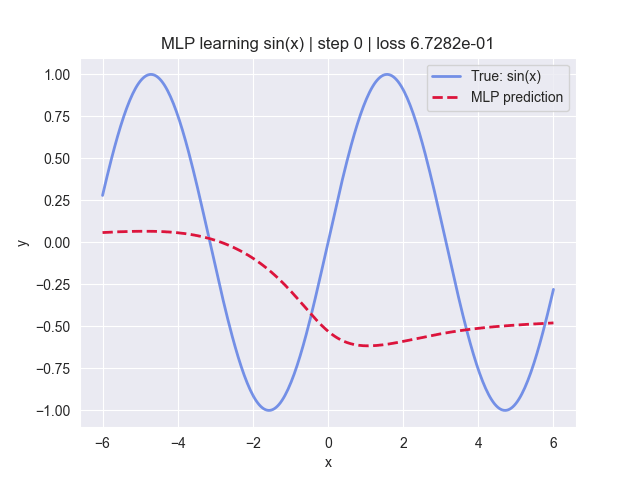

In [29]:
fn_sin, x_min, x_max = TARGET_FUNCTIONS["sin(x)"][0], *TARGET_FUNCTIONS["sin(x)"][1]
x_s, y_s, x_t_s, y_t_s = generate_data(fn_sin, n=300, x_min=x_min, x_max=x_max)

model_sin = MLP(hidden=32)
model_sin, hist_sin = train(model_sin, x_t_s, y_t_s, steps=3000, lr=1e-3, record_every=50)

gif_path = animate_training(hist_sin, x_s, y_s, fn_name="sin(x)", gif_path="mlp_convergence.gif")

# Display GIF inline
data = Path(gif_path).read_bytes()
b64 = base64.b64encode(data).decode("utf-8")
HTML(f'<img src="data:image/gif;base64,{b64}" style="max-width:100%" />')

How the network width influences the approximation ?

In [30]:
widths = [4, 8, 16, 32, 64]
fn_sin = TARGET_FUNCTIONS["sin(x)"][0]
x_w, y_w, x_tw, y_tw = generate_data(fn_sin, n=300, x_min=-2, x_max=2)

width_results = {}

print(f"{'Width':>8}{'MSE':>12}")
print("-" * 32)
for h in widths:
    m = MLP(hidden=h)
    m, _ = train(m, x_tw, y_tw, steps=3000, lr=1e-3, record_every=3000)
    with torch.no_grad():
        pred = m(x_tw).detach().cpu().numpy()
    mse = float(np.mean((pred - y_w) ** 2))
    width_results[h] = (pred, mse)
    print(f"{h:>8}  {mse:>12.6f}")


   Width         MSE
--------------------------------
       4      0.001262
       8      0.000486
      16      0.000193
      32      0.000054
      64      0.000010


The results show that as we increase the width of the hidden layers, the MLP's approximation of function (in our example sin(x)) improves, we can observe this by the decreasing MSE. This shows that wider networks have greater capacity to capture complex patterns in the data, allowing them to better approximate continuous functions.

Set of functions and their MLP's approximations

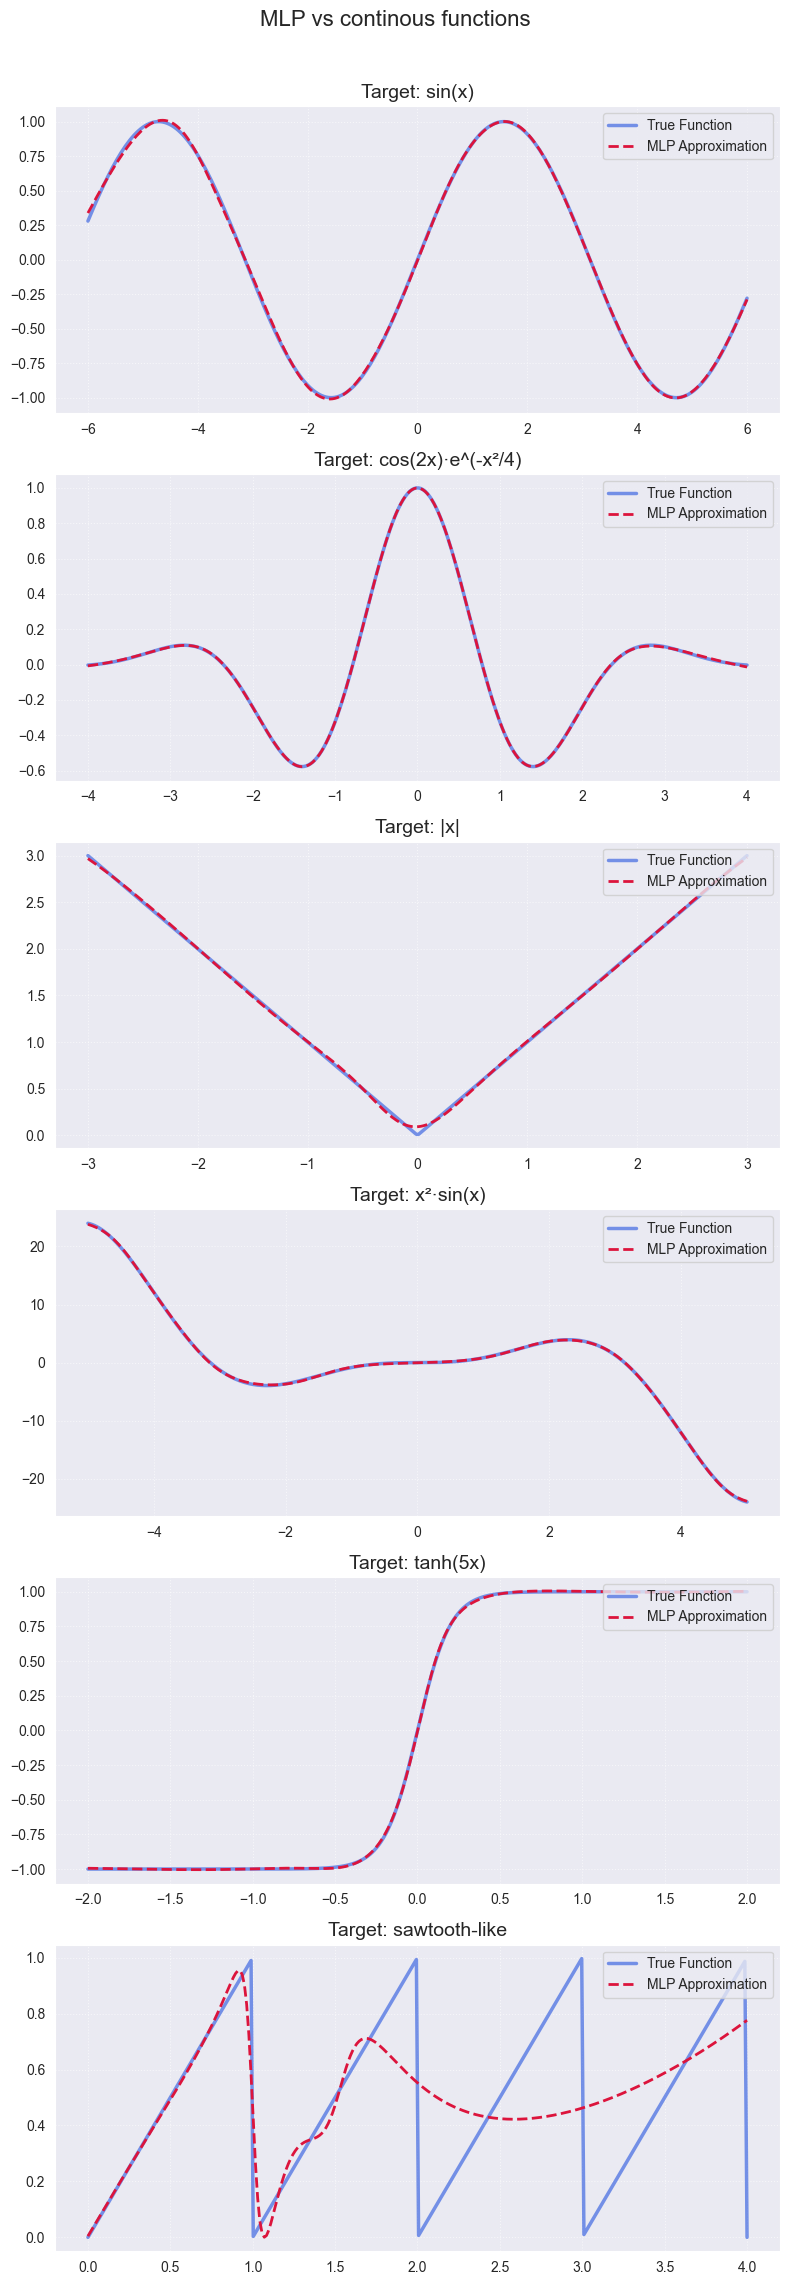

In [31]:
trained_data = []

for name, (fn, (x_min, x_max)) in TARGET_FUNCTIONS.items():
    # generate training data for the current function
    x_np, y_np, x_t, y_t = generate_data(fn, n=300, x_min=x_min, x_max=x_max)

    # creation and training of the MLP model
    model = MLP(hidden=32).to(device)
    model, _ = train(model, x_t, y_t, steps=2500, lr=1e-3, record_every=2500) #second argument returned by the unction is empty because we dont need history for this part

    # without the gradient to save memory and computation
    with torch.no_grad():
        pred = model(x_t).detach().cpu().numpy()
    trained_data.append((name, x_np, y_np, pred))


num_plots = len(trained_data)
fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(8, 4 * num_plots))
fig.suptitle("MLP vs continous functions", fontsize=16)

if num_plots == 1: axes = [axes]

for i, (name, x, y, pred) in enumerate(trained_data):
    ax = axes[i]

    ax.plot(x.flatten(), y.flatten(), label="True Function", color='royalblue',
            linewidth=2.5, alpha=0.7)
    ax.plot(x.flatten(), pred.flatten(), label="MLP Approximation", color='crimson',
            linewidth=2, linestyle='--')

    ax.set_title(f"Target: {name}", fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

tu jakas konkluzja ogolnei ta ostatnia funckja jest taka zjebana bo tak mialo byc ona nie jest continous wiec to jest negative control, ale ogolnie widac ze mlp jest w stanie dobrze przyblizyc te funkcje, nawet te bardziej skomplikowane, co pokazuje jego zdolnosc do aproksymacji duzej klasy funkcji ciaglych.

References


Documentation and tutorials:


PyTorch Documentation: [Build the Neural Network](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html).
PyTorch Documentation: [Optimization Loop](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).

 Tools:


 Google Gemini Pro: Used for generating diverse mathematical test functions and assisting with chart visualization logic and code structure.

Other resources:


S. Soni:[PyTorch Neural Networks: A Complete Guide](https://medium.com/@sachinsoni600517/pytorch-neural-networks-a-complete-guide-059e236559ff).
M. Nazari: [Building a Simple MLP from Scratch using PyTorch](https://medium.com/@mn05052002/building-a-simple-mlp-from-scratch-using-pytorch-7d50ca66512b).
R. Potluri [Neural Networks Notebook Example](https://github.com/rohitpotluri/medium/blob/main/Neural_Networks.ipynb).

